In [3]:
# Everything for fine-tuning AND serving a chatbot on Apple Silicon.
# No bitsandbytes (CUDA-only on Nvidia).
!pip install -q -U transformers datasets peft accelerate
!pip install -q -U evaluate rouge_score sacrebleu
!pip install -q -U matplotlib seaborn pandas

In [1]:
import gc, torch
gc.collect()
torch.mps.empty_cache()

In [2]:
import os, json, math, random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, TextStreamer,
    TrainingArguments, Trainer, DataCollatorForSeq2Seq, set_seed
)
from peft import LoraConfig, get_peft_model, PeftModel

SEED = 42
set_seed(SEED); random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# Apple Silicon -> MPS; Nvidia -> CUDA; else CPU
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print("Device:", DEVICE)

MAX_LEN = 512  # max tokens per training example

Device: mps


In [3]:
# Your domain data. For instruct models, teach STYLE/FORMAT, not new facts.
# A few hundred consistent examples is where real results start; this demo is small.
if not os.path.exists("dataset.json"):
    data = [
        {"prompt": "How do I reset my NimbusCloud password?",
         "response": "Go to Settings → Security → Reset Password. We'll email a reset link that expires in 15 minutes."},
        {"prompt": "What regions is NimbusCloud available in?",
         "response": "NimbusCloud runs in us-east-1, us-west-2, eu-west-2, and ap-south-1, with more on the roadmap."},
        {"prompt": "How do I rotate my API key?",
         "response": "Go to Settings → API Keys, click Rotate, and update your apps within 24 hours. The old key works during that grace period."},
        {"prompt": "Does NimbusCloud have automatic backups?",
         "response": "Yes — Pro and Enterprise plans get daily backups retained for 30 days. You can also snapshot manually from the Backups tab."},
        {"prompt": "Why am I getting 429 errors?",
         "response": "A 429 means you hit the rate limit: 60 req/min on Starter, 600 on Pro. Add exponential backoff or upgrade."},
        {"prompt": "How do I add a teammate?",
         "response": "Open the project, click Members → Invite, enter their email, and assign a role. The invite link is valid for 7 days."},
        {"prompt": "Can I use a custom domain?",
         "response": "Yes. Under Domains, add your domain and create the shown CNAME record. SSL provisions automatically once DNS propagates."},
        {"prompt": "What happens to my data if I cancel?",
         "response": "Your data is kept read-only for 30 days so you can export it, then permanently deleted."},
        {"prompt": "How do I enable two-factor authentication?",
         "response": "Go to Settings → Security → Two-Factor, scan the QR code with an authenticator app, and confirm the 6-digit code. Save your backup codes."},
        {"prompt": "How do I contact support?",
         "response": "Pro and Enterprise users can open a ticket from the Help menu or email support@nimbuscloud.example. Enterprise also gets 24/7 phone support."},
    ]
    with open("dataset.json", "w") as f:
        json.dump(data, f, indent=2)
    print("Wrote demo dataset.json")

ds = load_dataset("json", data_files="dataset.json", split="train").shuffle(seed=SEED)
split = ds.train_test_split(test_size=0.2, seed=SEED)
train_raw, test_raw = split["train"], split["test"]
print(f"Train: {len(train_raw)} | Test: {len(test_raw)}")

Train: 8 | Test: 2


In [4]:
# Fine-tunes ANY instruct model with LoRA and saves the adapter.
# Memory-lean version for 16GB Apple Silicon: gradient checkpointing + small LoRA.

def finetune(model_id, output_dir, epochs=3, lr=1e-4):
    print(f"\n=== Fine-tuning {model_id} ===")

    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    mdl = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16).to(DEVICE)
    mdl.config.use_cache = False           # required during training
    mdl.gradient_checkpointing_enable()    # trades a little speed for much less memory

    # LoRA: freeze base weights, train tiny adapter matrices.
    # Lean setup — rank 4, only q_proj/v_proj — to fit 16GB unified memory.
    lora = LoraConfig(
        r=4, lora_alpha=8, lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "v_proj"],
    )
    mdl = get_peft_model(mdl, lora)
    mdl.enable_input_require_grads()       # needed for grad checkpointing + LoRA to play nice
    mdl.print_trainable_parameters()

    # Tokenize with prompt masking — loss only on the response (-100 = ignore).
    # Render template to a STRING first, then tokenize to plain int lists
    # (tokenize=True can return an Encoding object that Arrow can't store).
    def tok_fn(ex):
        user = [{"role": "user", "content": ex["prompt"]}]
        full = [{"role": "user", "content": ex["prompt"]},
                {"role": "assistant", "content": ex["response"]}]

        prompt_text = tok.apply_chat_template(user, add_generation_prompt=True, tokenize=False)
        full_text   = tok.apply_chat_template(full, add_generation_prompt=False, tokenize=False)

        p_ids = tok(prompt_text, add_special_tokens=False)["input_ids"]
        f_ids = tok(full_text,   add_special_tokens=False)["input_ids"][:MAX_LEN]

        labels = list(f_ids)
        for i in range(min(len(p_ids), len(f_ids))):
            labels[i] = -100

        return {"input_ids": f_ids, "attention_mask": [1]*len(f_ids), "labels": labels}

    tr = train_raw.map(tok_fn, remove_columns=train_raw.column_names)
    te = test_raw.map(tok_fn, remove_columns=test_raw.column_names)
    collator = DataCollatorForSeq2Seq(tok, model=mdl, label_pad_token_id=-100, padding=True)

    args = TrainingArguments(
        output_dir=output_dir,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
        num_train_epochs=epochs,
        learning_rate=lr,
        bf16=False, fp16=False,            # keep both off on MPS
        logging_steps=2, eval_strategy="epoch", save_strategy="no",
        report_to="none", optim="adamw_torch",
        warmup_steps=5, lr_scheduler_type="cosine",
        gradient_checkpointing=True,       # match the model setting above
    )

    trainer = Trainer(model=mdl, args=args, train_dataset=tr, eval_dataset=te,
                      data_collator=collator, processing_class=tok)
    trainer.train()

    mdl.save_pretrained(output_dir)
    tok.save_pretrained(output_dir)
    print(f"Saved adapter to {output_dir}")
    return trainer

In [5]:
QWEN_BASE = "Qwen/Qwen2.5-1.5B-Instruct"
qwen_trainer = finetune(QWEN_BASE, "qwen-lora-adapter", epochs=5, lr=1e-4)


=== Fine-tuning Qwen/Qwen2.5-1.5B-Instruct ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 544,768 || all params: 1,544,259,072 || trainable%: 0.0353


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,3.288788
2,2.816438,3.288592
3,2.816438,3.287062
4,2.813899,3.282182
5,2.813899,3.275818


Saved adapter to qwen-lora-adapter


In [6]:
# Llama is GATED. Before this works you must have:
#   1. A Hugging Face account
#   2. Requested AND been granted access at:
#      https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
#   3. A Read token from https://huggingface.co/settings/tokens

from huggingface_hub import login
login()  # a box appears — paste your hf_... token and press enter

In [7]:

LLAMA_BASE = "meta-llama/Llama-3.2-3B-Instruct"
llama_trainer = finetune(LLAMA_BASE, "llama-lora-adapter", epochs=5, lr=1e-4)


=== Fine-tuning meta-llama/Llama-3.2-3B-Instruct ===


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


trainable params: 1,146,880 || all params: 3,213,896,704 || trainable%: 0.0357


Epoch,Training Loss,Validation Loss
1,No log,4.060257
2,3.553973,4.059153
3,3.553973,4.055960
4,3.545441,4.050183
5,3.545441,4.042720


Saved adapter to llama-lora-adapter


In [8]:
# Attaches a saved LoRA adapter onto its base model, ready to chat.
def load_chatbot(base_id, adapter_dir):
    tok = AutoTokenizer.from_pretrained(adapter_dir)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    base = AutoModelForCausalLM.from_pretrained(base_id, dtype=torch.float16).to(DEVICE)
    mdl = PeftModel.from_pretrained(base, adapter_dir).to(DEVICE)
    mdl.config.use_cache = True   # fast generation
    mdl.eval()
    print(f"Chatbot ready: {base_id} + {adapter_dir}")
    return tok, mdl

# Pick which fine-tuned bot is "active". The chat/eval cells use whatever's loaded here.

# --- Qwen ---
tokenizer, model = load_chatbot(QWEN_BASE, "qwen-lora-adapter")

# --- Llama (uncomment to use instead; comment out the Qwen line above) ---
# tokenizer, model = load_chatbot(LLAMA_BASE, "llama-lora-adapter")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Chatbot ready: Qwen/Qwen2.5-1.5B-Instruct + qwen-lora-adapter


In [10]:
# The core chatbot brain. `history` carries prior turns so it remembers context.
@torch.no_grad()
def chat(user_message, history=None, system_prompt="You are a helpful assistant for NimbusCloud.",
         max_new_tokens=400, temperature=0.7):
    if history is None:
        history = []

    # Build the full message list: system + prior turns + new user message
    messages = [{"role": "system", "content": system_prompt}] + history
    messages.append({"role": "user", "content": user_message})

    # Return a dict (input_ids + attention_mask) and move it to the device.
    # return_dict=True makes this work across transformers versions.
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True
    ).to(model.device)

    # Remember how long the prompt was, so we can strip it from the output
    prompt_len = inputs["input_ids"].shape[1]

    # Generate the reply — pass the whole dict with **inputs
    output = model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        do_sample=True, temperature=temperature, top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
    )
    # Decode only the newly generated tokens (strip the prompt)
    reply = tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True).strip()

    # Save this turn into history so the next call remembers it
    history.append({"role": "user", "content": user_message})
    history.append({"role": "assistant", "content": reply})
    return reply, history

# Quick test — try a domain question AND an off-topic one to check general ability survived
reply, hist = chat("How do I rotate my API key?")
print("Domain  :", reply, "\n")

reply2, _ = chat("Explain photosynthesis in two sentences.")
print("General :", reply2)

Domain  : To rotate your API key, you can follow these general steps:

1. Log in to the management console of the service provider that issued your API key.
2. Navigate to the section where you manage or access your API keys.
3. Locate and select your API key by clicking on its name or ID.
4. Look for an option labeled "Rotate" or similar wording.
5. Click on this option to initiate the rotation process.
6. Follow any additional instructions provided during the rotation process.

The specific steps may vary depending on the service provider's platform or tool used to manage API keys. If you need more detailed information about rotating your API key, please provide me with the name of the service provider and their platform/tool. 

General : Photosynthesis is the process by which plants, algae, and some bacteria use sunlight to convert carbon dioxide and water into glucose and oxygen. The resulting oxygen is released into the atmosphere as a byproduct of this chemical reaction.


In [11]:
# Run, then type messages. 'quit' to stop, 'reset' to clear memory.
history = []
print("Chatbot ready. 'quit' to exit, 'reset' to clear memory.\n")
while True:
    user = input("You: ").strip()
    if user.lower() in ("quit", "exit"):
        print("Goodbye."); break
    if user.lower() == "reset":quit
        history = []; print("[memory cleared]\n"); continue
    reply, history = chat(user, history)
    print("Bot:", reply, "\n")

Chatbot ready. 'quit' to exit, 'reset' to clear memory.



You:  what do you mean by quantum entanglement?


Bot: Quantum entanglement is a fundamental phenomenon in quantum physics where pairs or groups of particles become linked together, so that the state of one particle can instantaneously affect the state of another, no matter how far apart they may be. This means that information cannot travel faster than the speed of light between them.
In other words, if two particles are entangled, then knowing the state of one will give you instant knowledge of the state of the other, even though there is no physical connection between them. This has important implications for our understanding of the nature of reality and the way we understand the universe. It also has potential applications in fields such as cryptography, teleportation, and computing. 



You:  quit


Goodbye.


In [12]:
# Feels like a real chatbot — tokens print as they generate.
@torch.no_grad()
def chat_stream(user_message, history=None, system_prompt="You are a helpful assistant for NimbusCloud.",
                max_new_tokens=400, temperature=0.7):
    if history is None:
        history = []
    messages = [{"role": "system", "content": system_prompt}] + history
    messages.append({"role": "user", "content": user_message})

    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True,
        return_tensors="pt", return_dict=True
    ).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    output = model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=True,
        temperature=temperature, top_p=0.9,
        pad_token_id=tokenizer.eos_token_id, streamer=streamer)
    reply = tokenizer.decode(output[0][prompt_len:], skip_special_tokens=True).strip()

    history.append({"role": "user", "content": user_message})
    history.append({"role": "assistant", "content": reply})
    return reply, history

print("Streaming:\n")
_, hist = chat_stream("Give me a 2-sentence summary of NimbusCloud backups.")

Streaming:

NimbusCloud offers cloud backup and recovery solutions that provide secure, scalable data protection across multiple regions and SaaS applications. With Nimble Cloud Backup, users can easily recover their data in minutes without downtime, ensuring business continuity and minimizing disruption.


In [13]:
# Simple no-history generate, for both the fine-tuned model and its base.
@torch.no_grad()
def gen(tok, mdl, prompt, max_new_tokens=180):
    msgs = [{"role": "user", "content": prompt}]
    inputs = tok.apply_chat_template(
        msgs, add_generation_prompt=True,
        return_tensors="pt", return_dict=True
    ).to(mdl.device)
    prompt_len = inputs["input_ids"].shape[1]
    out = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                       pad_token_id=tok.eos_token_id)
    return tok.decode(out[0][prompt_len:], skip_special_tokens=True).strip()

prompts    = [r["prompt"] for r in test_raw]
references = [r["response"] for r in test_raw]

# Fine-tuned predictions (active model from Cell 7)
ft_preds = [gen(tokenizer, model, p) for p in prompts]

# Base predictions (load the plain base once for comparison)
base_tok = AutoTokenizer.from_pretrained(QWEN_BASE)
if base_tok.pad_token is None:
    base_tok.pad_token = base_tok.eos_token
base_mdl = AutoModelForCausalLM.from_pretrained(QWEN_BASE, dtype=torch.float16).to(DEVICE).eval()
base_preds = [gen(base_tok, base_mdl, p) for p in prompts]

for p, b, f, r in zip(prompts[:2], base_preds, ft_preds, references):
    print("PROMPT:", p)
    print("BASE  :", b[:120])
    print("TUNED :", f[:120])
    print("REF   :", r[:120], "\n")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

PROMPT: How do I rotate my API key?
BASE  : To rotate your API key in most platforms or services that use OAuth 2.0 for authentication and authorization, you typica
TUNED : To rotate your API key in most platforms or services that use OAuth 2.0 for authentication and authorization, you typica
REF   : Go to Settings → API Keys, click Rotate, and update your apps within 24 hours. The old key works during that grace perio 

PROMPT: Why am I getting 429 errors?
BASE  : A 429 error code typically indicates that the server is overwhelmed with requests and cannot process your request at thi
TUNED : A 429 error code typically indicates that the server is overwhelmed with requests and cannot process your request at thi
REF   : A 429 means you hit the rate limit: 60 req/min on Starter, 600 on Pro. Add exponential backoff or upgrade. 



In [14]:
import evaluate
rouge = evaluate.load("rouge")
bleu  = evaluate.load("sacrebleu")

def text_metrics(preds, refs):
    r = rouge.compute(predictions=preds, references=refs)
    b = bleu.compute(predictions=preds, references=[[x] for x in refs])
    return {"ROUGE-1": r["rouge1"], "ROUGE-2": r["rouge2"],
            "ROUGE-L": r["rougeL"], "BLEU": b["score"]/100.0}

ft_metrics   = text_metrics(ft_preds, references)
base_metrics = text_metrics(base_preds, references)

# Perplexity (lower = better). Build masked label rows like in training.
def to_eval_rows(tok, raws):
    rows = []
    for ex in raws:
        user = [{"role": "user", "content": ex["prompt"]}]
        full = [{"role": "user", "content": ex["prompt"]},
                {"role": "assistant", "content": ex["response"]}]
        prompt_text = tok.apply_chat_template(user, add_generation_prompt=True, tokenize=False)
        full_text   = tok.apply_chat_template(full, add_generation_prompt=False, tokenize=False)
        p_ids = tok(prompt_text, add_special_tokens=False)["input_ids"]
        f_ids = tok(full_text,   add_special_tokens=False)["input_ids"][:MAX_LEN]
        labels = list(f_ids)
        for i in range(min(len(p_ids), len(f_ids))): labels[i] = -100
        rows.append({"input_ids": f_ids, "attention_mask":[1]*len(f_ids), "labels":labels})
    return rows

from torch.utils.data import DataLoader
@torch.no_grad()
def perplexity(tok, mdl, raws):
    mdl.eval()
    coll = DataLoader(to_eval_rows(tok, raws), batch_size=2,
                      collate_fn=DataCollatorForSeq2Seq(tok, model=mdl, label_pad_token_id=-100, padding=True))
    tot_loss, tot_tok = 0.0, 0
    for batch in coll:
        batch = {k: v.to(mdl.device) for k, v in batch.items()}
        out = mdl(**batch)
        n = (batch["labels"] != -100).sum().item()
        tot_loss += out.loss.item()*n; tot_tok += n
    return math.exp(tot_loss/tot_tok)

ft_ppl   = perplexity(tokenizer, model, test_raw)
base_ppl = perplexity(base_tok, base_mdl, test_raw)

print("Fine-tuned:", {k: round(v,4) for k,v in ft_metrics.items()}, "| PPL", round(ft_ppl,2))
print("Base      :", {k: round(v,4) for k,v in base_metrics.items()}, "| PPL", round(base_ppl,2))

Fine-tuned: {'ROUGE-1': np.float64(0.1285), 'ROUGE-2': np.float64(0.0393), 'ROUGE-L': np.float64(0.0959), 'BLEU': 0.0049} | PPL 26.46
Base      : {'ROUGE-1': np.float64(0.1298), 'ROUGE-2': np.float64(0.0396), 'ROUGE-L': np.float64(0.097), 'BLEU': 0.0049} | PPL 26.81


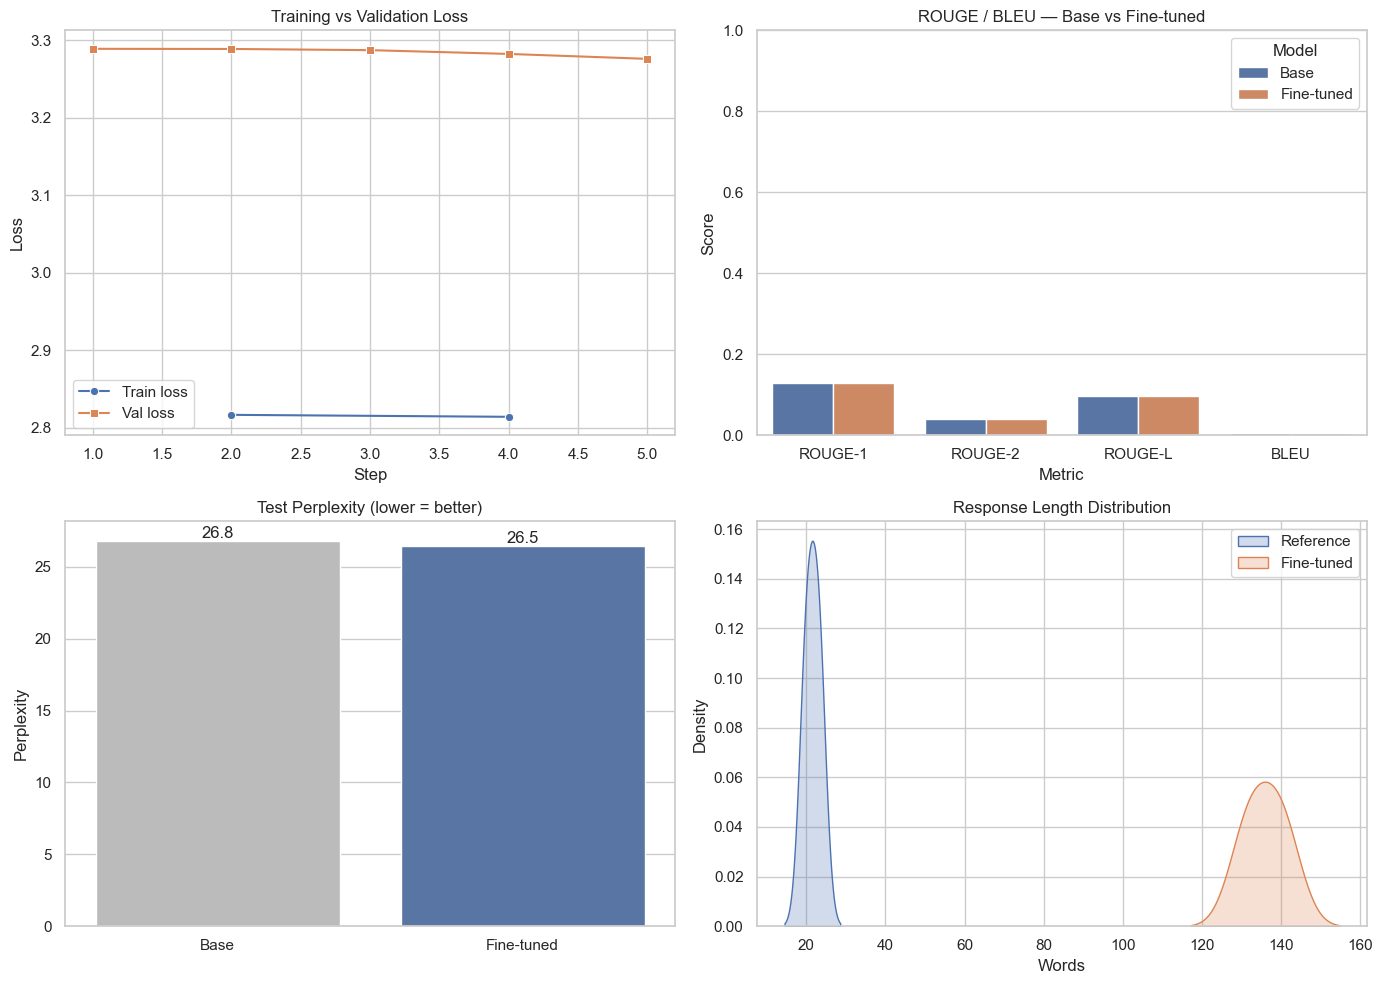

In [15]:
log = pd.DataFrame(qwen_trainer.state.log_history)  # use llama_trainer if evaluating Llama

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Train vs validation loss
ax = axes[0, 0]
tr = log.dropna(subset=["loss"]); ev = log.dropna(subset=["eval_loss"])
sns.lineplot(x=tr["step"], y=tr["loss"], marker="o", label="Train loss", ax=ax)
if not ev.empty:
    sns.lineplot(x=ev["step"], y=ev["eval_loss"], marker="s", label="Val loss", ax=ax)
ax.set_title("Training vs Validation Loss"); ax.set_xlabel("Step"); ax.set_ylabel("Loss")

# (2) ROUGE/BLEU base vs fine-tuned
ax = axes[0, 1]
mdf = pd.DataFrame([{"Metric":k,"Score":v,"Model":"Base"} for k,v in base_metrics.items()] +
                   [{"Metric":k,"Score":v,"Model":"Fine-tuned"} for k,v in ft_metrics.items()])
sns.barplot(data=mdf, x="Metric", y="Score", hue="Model", ax=ax)
ax.set_title("ROUGE / BLEU — Base vs Fine-tuned"); ax.set_ylim(0, 1)

# (3) Perplexity (lower = better)
ax = axes[1, 0]
sns.barplot(x=["Base","Fine-tuned"], y=[base_ppl, ft_ppl],
            hue=["Base","Fine-tuned"], palette=["#bbbbbb","#4c72b0"], legend=False, ax=ax)
ax.set_title("Test Perplexity (lower = better)"); ax.set_ylabel("Perplexity")
for i, v in enumerate([base_ppl, ft_ppl]): ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")

# (4) Response length distribution
ax = axes[1, 1]
ref_len = [len(r.split()) for r in references]; ft_len = [len(p.split()) for p in ft_preds]
sns.kdeplot(ref_len, fill=True, label="Reference", ax=ax)
sns.kdeplot(ft_len,  fill=True, label="Fine-tuned", ax=ax)
ax.set_title("Response Length Distribution"); ax.set_xlabel("Words"); ax.legend()

plt.tight_layout(); plt.show()